In [3]:
import sys
sys.path.append('../../../')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

from scipy.special import gammaln
from scipy.stats import chi2, multivariate_normal

from LRM.plotting import set_plot_style
from LRM.CMP1D import CMP1D, SmoothedEmpiricalDensity1D

set_plot_style()

SAVE = False

In [4]:
def sample_com_poisson(lam, nu, size=1000, seed=1):
    """
    Sample from Conway-Maxwell-Poisson using rejection sampling.
    Assumes fixed lambda (lam) and nu.
    """
    def compute_Z(lam, nu, k_max=100):
        """
        Compute the normalizing constant Z(λ, ν) by truncating the infinite sum.
        """
        k = np.arange(0, k_max + 1)
        log_terms = k * np.log(lam) - nu * gammaln(k + 1)
        Z = np.sum(np.exp(log_terms))
        return Z

    def com_poisson_pmf(k, lam, nu, normalize=False, k_max=100):
        if normalize:
            Z = compute_Z(lam, nu, k_max)
        else:
            Z=1
            
        log_pmf = k * np.log(lam) - nu * gammaln(k + 1) - np.log(Z)
        return np.exp(log_pmf)
    
    np.random.seed(seed)
    
    samples = []
    # Use Poisson as proposal distribution with same lambda
    proposal = np.random.poisson(lam, size * 10)

    # Compute (unnormalized) PMFs
    max_k = np.max(proposal)
    pmf_vals = np.array([com_poisson_pmf(k, lam, nu) for k in range(max_k + 1)])
    M = np.max(pmf_vals / (np.exp(-lam) * lam**np.arange(max_k + 1) / np.exp(gammaln(np.arange(max_k + 1) + 1))))

    for k in proposal:
        p = com_poisson_pmf(k, lam, nu)
        q = np.exp(-lam) * lam**k / np.exp(gammaln(k + 1))  # Poisson PMF
        if np.random.rand() < (p / (M * q)):
            samples.append(k)
            if len(samples) >= size:
                break

    return np.array(samples)

In [12]:
def transform_logtheta_theta(mu_X, Sigma_X):

    mu1, mu2 = mu_X.flatten()
    sigma11, sigma12 = Sigma_X[0, 0], Sigma_X[0, 1]
    sigma22 = Sigma_X[1, 1]

    # Compute E[theta1] = E[exp(x1)]
    E_theta1 = np.exp(mu1 + 0.5 * sigma11)

    # Mean vector
    mu_Y = np.array([
        E_theta1,
        mu2
    ])

    # Variance of exp(x1)
    var_theta1 = (np.exp(sigma11) - 1) * np.exp(2 * mu1 + sigma11)

    # Covariance between exp(x1) and x2
    cov_theta1_theta2 = np.exp(mu1 + 0.5 * sigma11) * sigma12

    # Covariance matrix
    Sigma_Y = np.array([
        [var_theta1,             cov_theta1_theta2],
        [cov_theta1_theta2,      sigma22]
    ])

    return mu_Y.reshape(-1,1), Sigma_Y


def transform_theta_logtheta(mu_X, Sigma_X):

    mu_X = np.asarray(mu_X)
    Sigma_X = np.asarray(Sigma_X)

    theta1, theta2 = mu_X
    if theta1 <= 0:
        raise ValueError("theta1 must be positive for log transformation.")

    # g(mu_X)
    mu_Y = np.array([np.log(theta1), theta2])

    # Jacobian of g at mu_X
    J = np.array([
        [1/theta1, 0],
        [0,        1]
    ])

    # Covariance after transformation
    Sigma_Y = J @ Sigma_X @ J.T

    return mu_Y.reshape(-1,1), Sigma_Y

In [11]:
n_list = [100*2**i for i in range(12)]
datasets = []
for n in n_list:
    datasets.append(sample_com_poisson(lam=4.0, nu=1.25, size=n))

In [14]:
prior = multivariate_normal(mean=[3.0, 3.0], cov=[[1.0, 0.0], [0.0, 1.0]])
prior_mean, prior_cov = transform_theta_logtheta(prior.mean, prior.cov)

means, covs = [], []

for i, data in enumerate(datasets):
    print(i)
    empirical = SmoothedEmpiricalDensity1D(alpha=0.0)
    empirical.fit(data)

    cmp = CMP1D(empirical=empirical)

    beta, _, _ = cmp.fit_coverage(data=data, prior_mean=prior_mean, prior_cov=prior_cov, verbose=True, B=100)

    posterior = cmp.posterior(data, beta=beta, mu_prior=prior_mean, Sigma_prior=prior_cov)

    mean, cov = transform_logtheta_theta(posterior.mean, posterior.cov)

    means.append(mean)
    covs.append(cov)

0
[scipy] beta*: 0.191109, coverage: 0.9500 (target 0.9500); fun=0, success=True
1
[scipy] beta*: 0.355359, coverage: 0.9600 (target 0.9500); fun=0.0001, success=True
2
[scipy] beta*: 0.440223, coverage: 0.9500 (target 0.9500); fun=0, success=True
3
[scipy] beta*: 0.490231, coverage: 0.9700 (target 0.9500); fun=0.0004, success=True
4
[scipy] beta*: 0.434203, coverage: 0.9600 (target 0.9500); fun=0.0001, success=True
5
[scipy] beta*: 0.517997, coverage: 0.9700 (target 0.9500); fun=0.0004, success=True
6
[scipy] beta*: 0.902222, coverage: 0.9500 (target 0.9500); fun=0, success=True
7
[scipy] beta*: 0.902141, coverage: 0.9400 (target 0.9500); fun=0.0001, success=True
8
[scipy] beta*: 0.512544, coverage: 0.9600 (target 0.9500); fun=0.0001, success=True
9
[scipy] beta*: 0.687311, coverage: 0.9500 (target 0.9500); fun=0, success=True
10
[scipy] beta*: 0.809872, coverage: 0.9400 (target 0.9500); fun=0.0001, success=True
11
[scipy] beta*: 0.659553, coverage: 0.9800 (target 0.9500); fun=0.0009,

In [50]:
import numpy as np
import matplotlib.pyplot as plt


def plot_cmp_posterior_results(
    means,
    covs,
    true_params=(4.0, 1.25),
    ci_mult=1.96,
    figsize=(7, 5),
):
    """
    Plot posterior mean +/- ci_mult * posterior marginal sd
    for theta_1 and theta_2.

    Robust to means/covs whose entries are small arrays rather than pure scalars.
    """

    x = np.asarray(n_list)

    theta1_mean = np.array([float(np.squeeze(m[0])) for m in means])
    theta2_mean = np.array([float(np.squeeze(m[1])) for m in means])

    theta1_sd = np.array([float(np.sqrt(np.squeeze(C[0, 0]))) for C in covs])
    theta2_sd = np.array([float(np.sqrt(np.squeeze(C[1, 1]))) for C in covs])

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=figsize,
        sharex=True,
        constrained_layout=True,
    )

    # Row 1: theta_1
    axes[0].plot(
        x,
        theta1_mean,
        marker="o",
        linewidth=1.5,
        label="Posterior mean",
        color="cornflowerblue",
    )
    axes[0].fill_between(
        x,
        theta1_mean - ci_mult * theta1_sd,
        theta1_mean + ci_mult * theta1_sd,
        alpha=0.2,
        label=fr"$\pm {ci_mult}$ posterior s.d.",
        color= "cornflowerblue",
    )
    axes[0].axhline(
        true_params[0],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="True value",
    )
    axes[0].set_ylabel(r"$\theta_1$")

    # Row 2: theta_2
    axes[1].plot(
        x,
        theta2_mean,
        marker="o",
        linewidth=1.5,
        label="Posterior mean",
        color= "cornflowerblue"
    )
    axes[1].fill_between(
        x,
        theta2_mean - ci_mult * theta2_sd,
        theta2_mean + ci_mult * theta2_sd,
        alpha=0.2,
        label=fr"$\pm {ci_mult}$ posterior s.d.",
        color= "cornflowerblue",
    )
    axes[1].axhline(
        true_params[1],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="True value",
    )
    axes[1].set_ylabel(r"$\theta_2$", fontsize=16)
    axes[1].set_xlabel(r"$n$", fontsize=16)
    axes[1].set_xscale("log")
    axes[1].set_xlim(n_list[0], n_list[-1]+100000)

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(frameon=False)

    return fig, axes

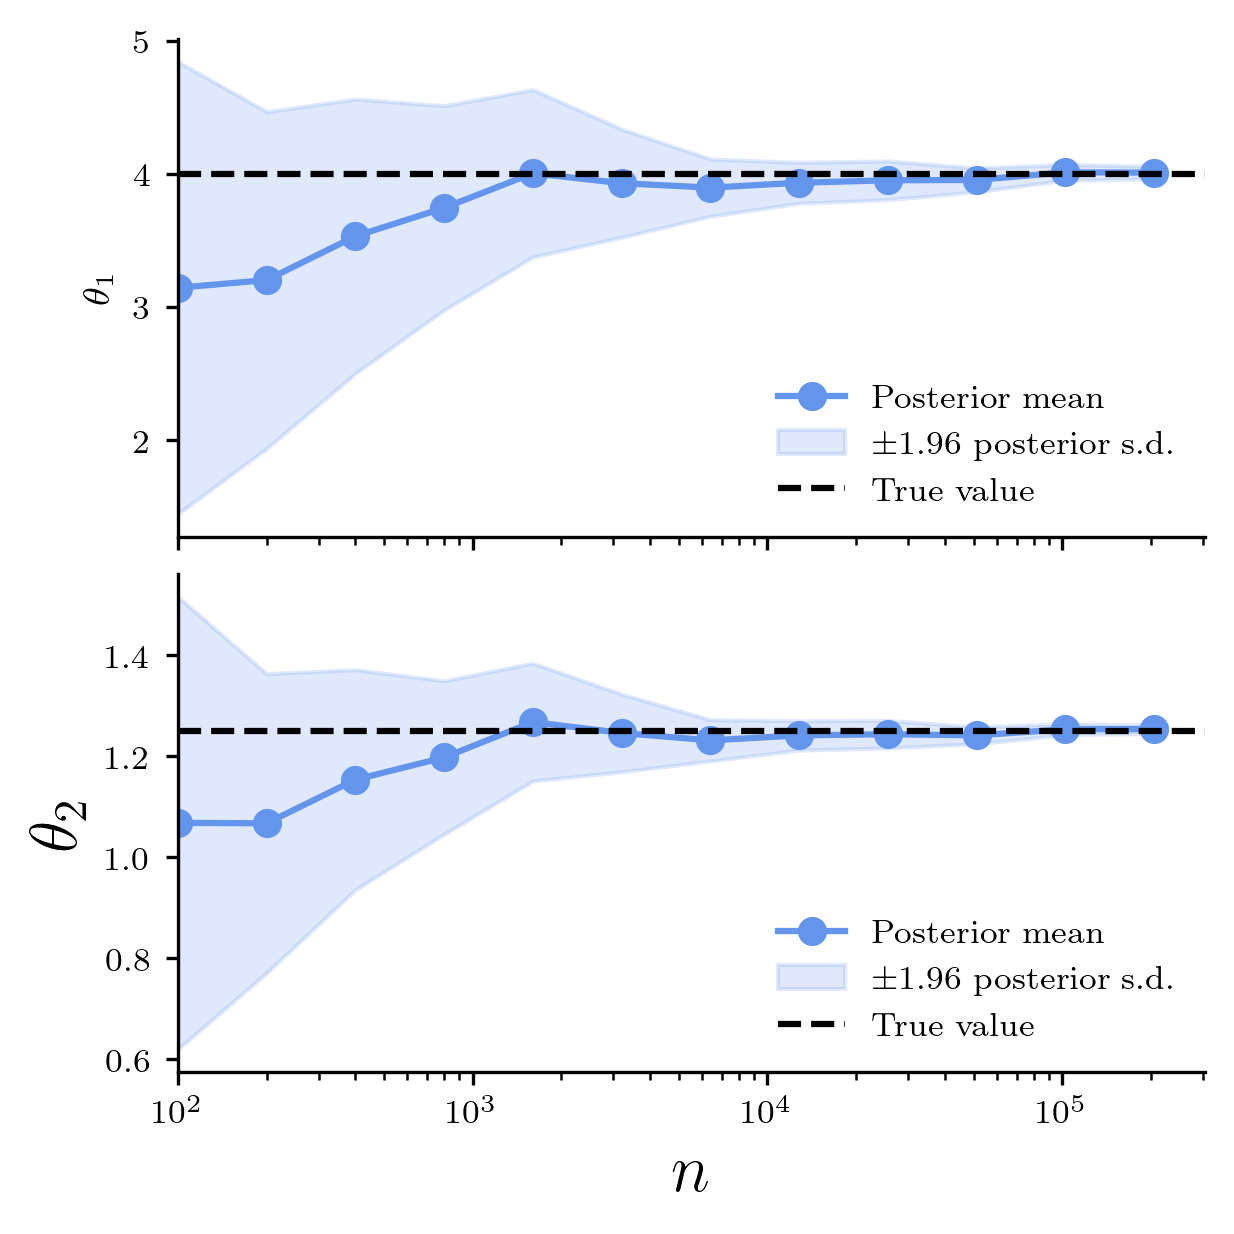

<Figure size 1920x1440 with 0 Axes>

In [52]:
fig, axes = plot_cmp_posterior_results(
    means=means,
    covs=covs,
    true_params=(4.0, 1.25),
    ci_mult=1.96,
    figsize=(4.0,4.0)
)

plt.show()
plt.savefig("./results/LRM-posterior-increasing-n.pdf", format="pdf", bbox_inches='tight')